In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
#import seaborn as sns

columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]

file_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Combined_SizeMorphology_Data_v2.xlsx"
data = pd.read_excel(file_path, usecols=columns)
print(len(data))
print(data.head())

9147
   N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index  Treatment  \
0    83  20.191787                0.994698          -1.896312      NaIO4   
1    69  15.991678                0.944322          -1.592018      NaIO4   
2    66  12.884921                0.824820          -1.042661      NaIO4   
3    95  11.358946                0.765687           0.452400  Untreated   
4    32  10.605089                0.883816          -1.077022      NaIO4   

         Date  
0  09-28-2023  
1   03-29-024  
2  03-22-2024  
3  09-28-2023  
4   03-29-024  


In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- ASSUMPTION: 'data' DataFrame is already loaded ---
# if standalone: data = pd.read_excel(r'path_to_file.xlsx')

# 1. Define Features
features_cols = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# 2. Standardize the data (StandardScaler)
scaler = StandardScaler()
features_scaled_array = scaler.fit_transform(data[features_cols])

# Create a DataFrame for the scaled data
data_scaled = pd.DataFrame(features_scaled_array, columns=features_cols, index=data.index)
data_scaled["Treatment"] = data["Treatment"]

# 3. Initialize Clustering setup
n_clusters = 5
results = []
cluster_counts_dict = {}

# Get list of unique treatments
unique_treatments = data["Treatment"].unique()
print(f"Found Treatments: {unique_treatments}")

# 4. Loop through each Treatment
for treatment in unique_treatments:
    print(f"Processing Treatment: {treatment}")
    
    # Filter for the current treatment (scaled data for clustering)
    subset_scaled = data_scaled[data_scaled["Treatment"] == treatment].drop("Treatment", axis=1)
    
    # Get the original feature values (for stats and sorting)
    subset_original = data.loc[subset_scaled.index, features_cols]
    
    # Initialize and fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(subset_scaled)
    raw_labels = kmeans.labels_
    
    # --- NEW SORTING STEP ---
    # We need to map the arbitrary K-Means labels (0-4) to an ordered set based on Euclid_2R
    
    # 1. Calculate the mean Euclid_2R for each raw cluster label
    cluster_means = []
    for i in range(n_clusters):
        # Handle cases where a cluster might be empty (rare but possible)
        if np.any(raw_labels == i):
            mean_size = subset_original.iloc[raw_labels == i]["Euclid_2R"].mean()
        else:
            mean_size = -1 # Push empty clusters to the start if they exist
        cluster_means.append((i, mean_size))
    
    # 2. Sort the list of tuples based on the mean size (second element)
    # This gives us the order from Smallest -> Largest
    cluster_means.sort(key=lambda x: x[1])
    
    # 3. Create a mapping dictionary: {Original_Label : New_Sorted_Rank}
    # Example: If raw label 3 had the smallest size, mapping[3] = 0
    mapping = {original_label: rank for rank, (original_label, _) in enumerate(cluster_means)}
    
    # 4. Apply the mapping to the labels array
    # Now, label 0 corresponds to the smallest aggregates, label 4 to the largest
    sorted_labels = np.vectorize(mapping.get)(raw_labels)
    
    # ------------------------
    
    # Store cluster counts using the new sorted labels
    counts = pd.Series(sorted_labels).value_counts().sort_index()
    cluster_counts_dict[treatment] = counts
    
    # Compute statistics for each cluster (iterating 0 to 4 ensures sorted order in Excel)
    for cluster_rank in range(n_clusters):
        # Filter original data using the SORTED labels
        cluster_data = subset_original.iloc[sorted_labels == cluster_rank]
        
        if not cluster_data.empty:
            stats = {
                "Treatment": treatment,
                "Cluster": cluster_rank, # 0 = Smallest, 4 = Largest
                "Count": len(cluster_data),
                # Mean
                **{f"{feat}_mean": cluster_data[feat].mean() for feat in features_cols},
                # Std Dev
                **{f"{feat}_std": cluster_data[feat].std() for feat in features_cols},
                # Min
                **{f"{feat}_min": cluster_data[feat].min() for feat in features_cols},
                # Max
                **{f"{feat}_max": cluster_data[feat].max() for feat in features_cols},
            }
            results.append(stats)

# 5. Formatting Outputs
df_results = pd.DataFrame(results)

# Aggregate cluster counts
cluster_counts_df = pd.DataFrame(cluster_counts_dict).fillna(0).astype(int)
cluster_counts_df = cluster_counts_df.T
cluster_counts_df.index.name = "Treatment"
# Rename columns to indicate size order
cluster_counts_df.columns = [f"Cluster {i} (Small->Large)" for i in range(n_clusters)]

# 6. Export results
output_path = r'Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Dispersed Cells Cluster Size and Morphology Data\treatment_results_SortedByEuclid_v1.xlsx'

try:
    with pd.ExcelWriter(output_path) as writer:
        df_results.to_excel(writer, sheet_name="Cluster_Stats", index=False)
        cluster_counts_df.to_excel(writer, sheet_name="Cluster_Counts", index=True)
        
    print(f"SUCCESS: Sorted results have been saved to '{output_path}'")

except Exception as e:
    print(f"ERROR: Could not save file. Close the Excel file if it is open. Details: {e}")

Found Treatments: ['NaIO4' 'Untreated' 'DNaseI' 'pH10' 'ProtK']
Processing Treatment: NaIO4
Processing Treatment: Untreated
Processing Treatment: DNaseI
Processing Treatment: pH10


C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\

Processing Treatment: ProtK
SUCCESS: Sorted results have been saved to 'Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Dispersed Cells Cluster Size and Morphology Data\treatment_results_SortedByEuclid_v1.xlsx'


In [5]:
# Parameters
data_columns = data.columns  # Assume all columns are included initially
exclude_columns = ['Treatment', 'Date']  # List of column names to exclude from z-transform

# Separate excluded columns and apply z-transform
included_columns = [col for col in data_columns if col not in exclude_columns]
scaler = StandardScaler()
data_scaled_array = scaler.fit_transform(data[included_columns])  # Scale numeric columns

# Combine scaled data with the "Treatment" column
treatment_column = data['Treatment'].values.reshape(-1, 1)  # Ensure it is a 2D array
date_column = data['Date'].values.reshape(-1, 1) # Ensure it is a 2D array
data_scaled_combined = np.hstack((data_scaled_array, treatment_column, date_column))

# Create a DataFrame with the original columns
data_scaled = pd.DataFrame(data_scaled_combined, columns=included_columns + exclude_columns)

# Display the original and scaled data for verification
print("Original Data:")
print(data)
print(len(data))

print("\nScaled Data:")
print(data_scaled.head())
print(len(data_scaled))

Original Data:
      N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index  Treatment  \
0       83  20.191787                0.994698          -1.896312      NaIO4   
1       69  15.991678                0.944322          -1.592018      NaIO4   
2       66  12.884921                0.824820          -1.042661      NaIO4   
3       95  11.358946                0.765687           0.452400  Untreated   
4       32  10.605089                0.883816          -1.077022      NaIO4   
...    ...        ...                     ...                ...        ...   
9142     1   0.700000                0.000000           0.000000       pH10   
9143     1   0.700000                0.000000           0.000000       pH10   
9144     1   0.700000                0.000000           0.000000       pH10   
9145     1   0.700000                0.000000           0.000000       pH10   
9146     1   0.700000                0.000000           0.000000       pH10   

            Date  
0     09-28-2023 

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define the columns
columns = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index", "Treatment", "Date"]

# Load the data
file_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Combined_SizeMorphology_Data_v2.xlsx"
data = pd.read_excel(file_path, usecols=columns)

print(len(data))
print(data.head())

# Define the columns to scale and those to exclude
scale_columns = ["Euclid_2R", "Shape_anisotropy_index","Asphericity_index"]
exclude_columns = ["N_cl", "Treatment", "Date"]

# Apply standard scaling only to selected columns
scaler = StandardScaler()
data_scaled_array = scaler.fit_transform(data[scale_columns])

# Create a DataFrame with scaled and unscaled columns
data_scaled = pd.DataFrame(data_scaled_array, columns=scale_columns)
data_scaled[exclude_columns] = data[exclude_columns].reset_index(drop=True)

# Display the original and scaled data for verification
print("Original Data:")
print(data)
print(len(data))

print("\nScaled Data:")
print(data_scaled.head())
print(len(data_scaled))


9147
   N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index  Treatment  \
0    83  20.191787                0.994698          -1.896312      NaIO4   
1    69  15.991678                0.944322          -1.592018      NaIO4   
2    66  12.884921                0.824820          -1.042661      NaIO4   
3    95  11.358946                0.765687           0.452400  Untreated   
4    32  10.605089                0.883816          -1.077022      NaIO4   

         Date  
0  09-28-2023  
1   03-29-024  
2  03-22-2024  
3  09-28-2023  
4   03-29-024  
Original Data:
      N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index  Treatment  \
0       83  20.191787                0.994698          -1.896312      NaIO4   
1       69  15.991678                0.944322          -1.592018      NaIO4   
2       66  12.884921                0.824820          -1.042661      NaIO4   
3       95  11.358946                0.765687           0.452400  Untreated   
4       32  10.605089           

In [7]:
data = data.dropna()
print(len(data))
scaled_data = data.dropna()
print(len(data_scaled))

9147
9147


In [8]:
scaled_data_numerical = data_scaled.drop(["Treatment", "Date"], axis=1)
print(scaled_data_numerical)
data_numerical = data.drop(["Treatment", "Date"], axis = 1) 
print(data_numerical)

      Euclid_2R  Shape_anisotropy_index  Asphericity_index  N_cl
0     16.531836                0.488576          -0.740624    83
1     12.680603                0.327736          -0.405155    69
2      9.831904               -0.053811           0.200487    66
3      8.432682               -0.242612           1.848724    95
4      7.741443                0.134550           0.162605    32
...         ...                     ...                ...   ...
9142  -1.340896               -2.687300           1.349973     1
9143  -1.340896               -2.687300           1.349973     1
9144  -1.340896               -2.687300           1.349973     1
9145  -1.340896               -2.687300           1.349973     1
9146  -1.340896               -2.687300           1.349973     1

[9147 rows x 4 columns]
      N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index
0       83  20.191787                0.994698          -1.896312
1       69  15.991678                0.944322          -1.592018


In [9]:
# Extract features for PCA (ignoring the Treatment column)
features = data[["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]]

# Standardize the data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply Kernel PCA with RBF kernel
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=None, fit_inverse_transform=True)
features_kpca = kpca.fit_transform(features_scaled)

# Inverse transform the data
features_reconstructed = kpca.inverse_transform(features_kpca)

# Convert back to DataFrame for easy interpretation
data_kpca = pd.DataFrame(
    features_kpca,
    columns=["PC1", "PC2"]
)
reconstructed_data_kpca = pd.DataFrame(
    scaler.inverse_transform(features_reconstructed),
    columns=features.columns
)

data_kpca["Treatment"] = data["Treatment"]

# Show transformed and reconstructed data
print("Transformed Data:")
print(data_kpca)
print(len(data_kpca))

print("\nReconstructed Data:")
print(reconstructed_data_kpca)
print(len(reconstructed_data_kpca))

Transformed Data:
           PC1       PC2  Treatment
0     0.419663 -0.025707      NaIO4
1     0.419686 -0.025709      NaIO4
2     0.419691 -0.025710      NaIO4
3     0.419663 -0.025707  Untreated
4     0.420472 -0.025792      NaIO4
...        ...       ...        ...
9142  0.912795 -0.515671       pH10
9143  0.912795 -0.515671       pH10
9144  0.912795 -0.515671       pH10
9145  0.912795 -0.515671       pH10
9146  0.912795 -0.515671       pH10

[9147 rows x 3 columns]
9147

Reconstructed Data:
           N_cl  Euclid_2R  Shape_anisotropy_index  Asphericity_index
0     10.254121   3.101329                0.763857          -0.026870
1     10.253999   3.101313                0.763847          -0.026812
2     10.253968   3.101309                0.763844          -0.026796
3     10.254122   3.101330                0.763857          -0.026871
4     10.249755   3.100752                0.763483          -0.024778
...         ...        ...                     ...                ...
9142   1.

In [10]:
data_kpca_numerical = data_kpca.drop("Treatment", axis=1)
print(data_kpca_numerical)
kpca_columns = ["PC1", "PC2", "Treatment"]

           PC1       PC2
0     0.419663 -0.025707
1     0.419686 -0.025709
2     0.419691 -0.025710
3     0.419663 -0.025707
4     0.420472 -0.025792
...        ...       ...
9142  0.912795 -0.515671
9143  0.912795 -0.515671
9144  0.912795 -0.515671
9145  0.912795 -0.515671
9146  0.912795 -0.515671

[9147 rows x 2 columns]


In [11]:
numerical_cols = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Convert numerical columns to float
for col in numerical_cols:
    scaled_data_numerical[col] = pd.to_numeric(scaled_data_numerical[col], errors='coerce')

In [12]:
print(scaled_data_numerical.dtypes)

Euclid_2R                 float64
Shape_anisotropy_index    float64
Asphericity_index         float64
N_cl                        int64
dtype: object


In [13]:
print(data_kpca_numerical.dtypes)

PC1    float64
PC2    float64
dtype: object


In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import StratifiedKFold

# Define the features to calculate stats for
features = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Define the number of clusters
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Perform 5-fold cross-validation using StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Prepare lists to store results
results = []
cluster_labels_all = []
cluster_counts = []

# Loop through each fold
for fold, (train_idx, test_idx) in enumerate(kf.split(data_kpca_numerical, np.zeros(len(data_kpca_numerical)))):
    # Get the test data for this fold
    fold_data = data.iloc[test_idx][features]
    
    # Apply k-means clustering
    kmeans.fit(data_kpca_numerical.iloc[test_idx])  # Ensure correct indexing
    cluster_labels = kmeans.labels_
    
    # Store cluster labels and counts
    cluster_labels_all.extend(cluster_labels)
    counts = pd.Series(cluster_labels).value_counts().sort_index()
    cluster_counts.append(counts)
    
    # Compute statistics for each cluster
    for cluster_num in range(n_clusters):
        # Filter data for the current cluster
        cluster_data = fold_data.iloc[np.where(cluster_labels == cluster_num)]
        
        if not cluster_data.empty:
            # Compute statistics for each feature
            stats = {
                "Cluster": cluster_num,
                "Fold": f"Fold {fold+1}",
                **{f"{feat}_mean": cluster_data[feat].mean() for feat in features},
                **{f"{feat}_std": cluster_data[feat].std() for feat in features},
                **{f"{feat}_min": cluster_data[feat].min() for feat in features},
                **{f"{feat}_max": cluster_data[feat].max() for feat in features},
            }
            results.append(stats)

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Aggregate cluster counts
cluster_counts_df = pd.DataFrame(cluster_counts).fillna(0).astype(int)
cluster_counts_df.index = [f"Fold {i+1}" for i in range(len(cluster_counts))]

# Export results to an Excel file
output_path = r'Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Dispersed Cells Cluster Size and Morphology Data\fold_results_with_centroids_KPCA_v10.xlsx'

with pd.ExcelWriter(output_path) as writer:
    # Write the main statistics
    df_results.to_excel(writer, sheet_name="Cluster_Stats", index=False)
    
    # Write the cluster counts across folds
    cluster_counts_df.to_excel(writer, sheet_name="Cluster_Counts", index=True)

print(f"Results have been saved to '{output_path}'")


C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\l

Results have been saved to 'Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Dispersed Cells Cluster Size and Morphology Data\fold_results_with_centroids_KPCA_v10.xlsx'


C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


In [13]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Perform KMeans clustering with k=5.
kmeans = KMeans(n_clusters=5, random_state=42)
scaled_data_numerical['Cluster'] = kmeans.fit_predict(scaled_data_numerical)

# Merge the cluster assignments back to the original data.
data['Cluster'] = scaled_data_numerical['Cluster']
data_numerical['Cluster'] = scaled_data_numerical['Cluster']

# Calculate feature statistics (mean, sd, min, max) for each K-Means class (cluster).
cluster_feature_stats = (
    data_numerical.groupby('Cluster')  # Group by cluster.
    .agg(['mean', 'std', 'min', 'max'])       # Compute required statistics.
)

# Flatten MultiIndex columns created by aggregation.
cluster_feature_stats.columns = ['_'.join(col).strip() for col in cluster_feature_stats.columns]

# Reset index for better readability and accessibility.
cluster_feature_stats = cluster_feature_stats.reset_index()

# Count the occurrences of each treatment per cluster for each date.
counts_per_date_cluster_treatment = (
    data.groupby(['Date', 'Cluster', 'Treatment']).size()
    .unstack(fill_value=0)  # Creates columns for each treatment with 0 as default.
)

# Export the results to Excel.
output_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\B_Biofilms and Machine Learning\K-MeansResults_ReleasedCells_NclUnscaled.xlsx"

# Example of dummy data for `cluster_counts` (ensure this exists in your workflow)
cluster_counts = data['Cluster'].value_counts().rename_axis('Cluster').reset_index(name='Count')

# Export to Excel
with pd.ExcelWriter(output_path) as writer:
    # Export the cluster feature statistics
    cluster_feature_stats.to_excel(writer, sheet_name="Cluster_Feature_Statistics", index=False)
    # Export other results
    cluster_counts.to_excel(writer, sheet_name="Cluster_Counts", index=False)
    data.to_excel(writer, sheet_name="Scaled_Data", index=False)
    # treatment_counts.to_excel(writer, sheet_name="Treatment_Counts", index=False)

    # Export the counts per date-cluster-treatment
    counts_per_date_cluster_treatment.to_excel(writer, sheet_name="Counts_Per_Date_Cluster")

print(f"Export completed: '{output_path}' created.")


C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Export completed: 'Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\B_Biofilms and Machine Learning\K-MeansResults_ReleasedCells_NclUnscaled.xlsx' created.


In [15]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score, v_measure_score,
    homogeneity_score, completeness_score, fowlkes_mallows_score
)

# 1️⃣ Perform KMeans clustering on Raw Data
kmeans_raw = KMeans(n_clusters=5, random_state=42)
data_numerical['Cluster_raw'] = kmeans_raw.fit_predict(data_numerical)

# 2️⃣ Perform KMeans clustering on Scaled Data
kmeans_scaled = KMeans(n_clusters=5, random_state=42)
scaled_data_numerical['Cluster_scaled'] = kmeans_scaled.fit_predict(scaled_data_numerical)

# 3️⃣ Compute similarity metrics between Raw vs Scaled clusterings
cluster_labels_raw = data_numerical['Cluster_raw']
cluster_labels_scaled = scaled_data_numerical['Cluster_scaled']

# Compute similarity metrics
similarity_metrics = {
    "Adjusted Rand Index": adjusted_rand_score(cluster_labels_raw, cluster_labels_scaled),
    "Normalized Mutual Info": normalized_mutual_info_score(cluster_labels_raw, cluster_labels_scaled),
    "V-measure": v_measure_score(cluster_labels_raw, cluster_labels_scaled),
    "Homogeneity": homogeneity_score(cluster_labels_raw, cluster_labels_scaled),
    "Completeness": completeness_score(cluster_labels_raw, cluster_labels_scaled),
    "Fowlkes-Mallows": fowlkes_mallows_score(cluster_labels_raw, cluster_labels_scaled)
}

# Convert metrics to DataFrame for exporting
df_similarity_metrics = pd.DataFrame(list(similarity_metrics.items()), columns=["Metric", "Score"])

# 4️⃣ (Optional but smart!) — calculate feature statistics for **scaled data clusters**
cluster_feature_stats_scaled = (
    data_numerical.assign(Cluster=scaled_data_numerical['Cluster_scaled'])
    .groupby('Cluster')
    .agg(['mean', 'std', 'min', 'max'])
)
cluster_feature_stats_scaled.columns = ['_'.join(col).strip() for col in cluster_feature_stats_scaled.columns]
cluster_feature_stats_scaled = cluster_feature_stats_scaled.reset_index()

# 5️⃣ Export everything to Excel
output_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\K-MeansResults_ReleasedCells_NclUnscaled_ComparisonMetrics.xlsx"

with pd.ExcelWriter(output_path) as writer:
    # Cluster feature stats for Raw
    cluster_feature_stats = (
        data_numerical.groupby('Cluster_raw')
        .agg(['mean', 'std', 'min', 'max'])
    )
    cluster_feature_stats.columns = ['_'.join(col).strip() for col in cluster_feature_stats.columns]
    cluster_feature_stats = cluster_feature_stats.reset_index()
    cluster_feature_stats.to_excel(writer, sheet_name="Cluster_Feature_Stats_Raw", index=False)

    # Cluster feature stats for Scaled
    cluster_feature_stats_scaled.to_excel(writer, sheet_name="Cluster_Feature_Stats_Scaled", index=False)

    # Similarity metrics between Raw and Scaled
    df_similarity_metrics.to_excel(writer, sheet_name="Cluster_Similarity_Metrics", index=False)

    # Full datasets with cluster labels
    data_numerical.to_excel(writer, sheet_name="Raw_Data_Clusters", index=False)
    scaled_data_numerical.to_excel(writer, sheet_name="Scaled_Data_Clusters", index=False)

print(f"Export completed: '{output_path}' created.")


C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Export completed: 'Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\K-MeansResults_ReleasedCells_NclUnscaled_ComparisonMetrics.xlsx' created.


In [16]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Perform KMeans clustering with k=5.
kmeans = KMeans(n_clusters=5, random_state=42)
scaled_data_numerical['Cluster'] = kmeans.fit_predict(scaled_data_numerical)

# Merge the cluster assignments back to the original data.
data['Cluster'] = scaled_data_numerical['Cluster']
data_numerical['Cluster'] = scaled_data_numerical['Cluster']

# Calculate feature statistics (mean, sd, min, max) for each K-Means class (cluster).
cluster_feature_stats = (
    data_numerical.groupby('Cluster')  # Group by cluster.
    .agg(['mean', 'std', 'min', 'max'])       # Compute required statistics.
)

# Flatten MultiIndex columns created by aggregation.
cluster_feature_stats.columns = ['_'.join(col).strip() for col in cluster_feature_stats.columns]

# Reset index for better readability and accessibility.
cluster_feature_stats = cluster_feature_stats.reset_index()

# Count the occurrences of each treatment per cluster for each date.
counts_per_date_cluster_treatment = (
    data.groupby(['Date', 'Cluster', 'Treatment']).size()
    .unstack(fill_value=0)  # Creates columns for each treatment with 0 as default.
)

# Calculate the number of times N_cl = 1 for all K-Means clusters and treatments.
ncl_1_counts = (
    data.assign(N_cl_1=(data['N_cl'] == 1).astype(int))  # Create a binary column for N_cl == 1.
    .groupby(['Cluster', 'Treatment'])['N_cl_1']        # Group by Cluster and Treatment.
    .sum()                                              # Sum the N_cl == 1 occurrences.
    .unstack(fill_value=0)                              # Fill missing cluster-treatment combinations with 0.
    .stack()                                            # Return to long format.
    .reset_index(name='N_cl_1_Count')                  # Reset the index and rename the count column.
)

# Export the results to Excel.
output_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\K-MeansResults_ReleasedCells_V8.xlsx"

# Example of dummy data for `cluster_counts` (ensure this exists in your workflow)
cluster_counts = data['Cluster'].value_counts().rename_axis('Cluster').reset_index(name='Count')

# Export to Excel
with pd.ExcelWriter(output_path) as writer:
    # Export the cluster feature statistics
    cluster_feature_stats.to_excel(writer, sheet_name="Cluster_Feature_Statistics", index=False)
    # Export the N_cl = 1 counts
    ncl_1_counts.to_excel(writer, sheet_name="N_cl_1_Counts", index=False)
    # Export other results
    cluster_counts.to_excel(writer, sheet_name="Cluster_Counts", index=False)
    data.to_excel(writer, sheet_name="Scaled_Data", index=False)
    # treatment_counts.to_excel(writer, sheet_name="Treatment_Counts", index=False)

    # Export the counts per date-cluster-treatment
    counts_per_date_cluster_treatment.to_excel(writer, sheet_name="Counts_Per_Date_Cluster")

print(f"Export completed: '{output_path}' created.")


C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Export completed: 'Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\K-MeansResults_ReleasedCells_V8.xlsx' created.


In [18]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import StratifiedKFold

# Assuming 'data' is your original dataset and 'data_kpca' is the transformed dataset

# Define the number of clusters
kmeans = KMeans(n_clusters=5, random_state=42)

# Define the features to calculate stats for
features = ["N_cl", "Euclid_2R", "Shape_anisotropy_index", "Asphericity_index"]

# Perform 5-fold cross-validation using StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Prepare the list to store results
results = []
cluster_labels_all = []  # Store all cluster labels across folds
data_points_all = []  # Store all data points across folds

# Loop through each fold
for fold, (train_idx, test_idx) in enumerate(kf.split(data_kpca_numerical, np.zeros(len(data_kpca)))):
    # Get the test data for this fold from the original data
    fold_data = data.iloc[test_idx][features]
    
    # Apply k-means clustering on the transformed data (data_kpca)
    kmeans.fit(data_kpca_numerical.iloc[test_idx])  # Make sure to index correctly with .iloc for rows
    cluster_labels = kmeans.labels_
    
    # Store the cluster labels for centroid and count calculations
    cluster_labels_all.append(cluster_labels)
    data_points_all.append(fold_data)

    # Compute statistics for each cluster in this fold
    for cluster_num in range(5):
        cluster_data = fold_data[cluster_labels == cluster_num]
        
        # Compute mean, std, min, and max for each feature in the cluster
        stats = {
            "Cluster": cluster_num,
            "Fold": f"Fold {fold+1}",
            "N_cl_mean": cluster_data["N_cl"].mean(),
            "N_cl_std": cluster_data["N_cl"].std(),
            "N_cl_min": cluster_data["N_cl"].min(),
            "N_cl_max": cluster_data["N_cl"].max(),
            "Euclid_2R_mean": cluster_data["Euclid_2R"].mean(),
            "Euclid_2R_std": cluster_data["Euclid_2R"].std(),
            "Euclid_2R_min": cluster_data["Euclid_2R"].min(),
            "Euclid_2R_max": cluster_data["Euclid_2R"].max(),
            "Shape_anisotropy_index_mean": cluster_data["Shape_anisotropy_index"].mean(),
            "Shape_anisotropy_index_std": cluster_data["Shape_anisotropy_index"].std(),
            "Shape_anisotropy_index_min": cluster_data["Shape_anisotropy_index"].min(),
            "Shape_anisotropy_index_max": cluster_data["Shape_anisotropy_index"].max(),
            "Asphericity_index_mean": cluster_data["Asphericity_index"].mean(),
            "Asphericity_index_std": cluster_data["Asphericity_index"].std(),
            "Asphericity_index_min": cluster_data["Asphericity_index"].min(),
            "Asphericity_index_max": cluster_data["Asphericity_index"].max(),
        }
        
        # Append the statistics to the results list
        results.append(stats)

# Convert the results list to a DataFrame
df_results = pd.DataFrame(results)

output_path = r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\1_Data Collection and Analysis\Dispersed Cells Cluster Size and Morphology Data\fold_results_with_centroids_KPCA_v7.xlsx"

# Export the DataFrame to an Excel file with multiple sheets
with pd.ExcelWriter(output_path) as writer:
    # Write the main statistics
    df_results.to_excel(writer, sheet_name="Cluster_Stats", index=False)
    
    # Write the cluster centroids across folds
    #centroids_df.to_excel(writer, sheet_name="Cluster_Centroids", index=True)
    
    # Write the cluster counts across folds
    cluster_counts_df.to_excel(writer, sheet_name="Cluster_Counts", index=True)

print("Results have been saved to 'kmeans_cluster_summary_across_folds.xlsx'")

C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\srpackard\AppData\Local\anaconda3\envs\softmatter\l

Results have been saved to 'kmeans_cluster_summary_across_folds.xlsx'


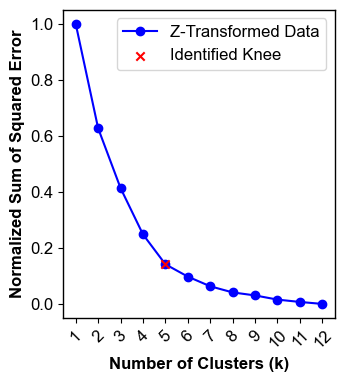

Optimal number of clusters (k) for Scaled Data: 5
Optimal number of clusters (k) for Unscaled Data: 3


In [21]:
from kneed import KneeLocator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Define the range of k-values
k_values = range(1, 13)  # K-values from 1 to 5

# Initialize lists to store inertia (error) values for the data
inertia_data = []
inertia_data_scaled = []

# Calculate inertia for both datasets across k-values
for k in k_values:
    # Perform K-Means on scaled data 
    kmeans_data_scaled = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans_data_scaled.fit(scaled_data_numerical)  # scaled data

    # Calculate inertia for scaled data
    inertia_data_scaled.append(kmeans_data_scaled.inertia_)
    
    # Perform K-Means on unscaled data 
    kmeans_data = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans_data.fit(data_kpca_numerical)  # unscaled data
    
    # Calculate inertia for unscaled data
    inertia_data.append(kmeans_data.inertia_)

# Normalize the inertia values to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape the inertia lists to 2D arrays for scaling
inertia_data = scaler.fit_transform(np.array(inertia_data).reshape(-1, 1)).flatten()
inertia_data_scaled = scaler.fit_transform(np.array(inertia_data_scaled).reshape(-1, 1)).flatten()

# Plotting the comparison of normalized inertia values for both datasets
plt.figure(figsize=(3.5, 4))

# Plot normalized inertia for scaled data
plt.plot(k_values, inertia_data_scaled, marker='o', linestyle='-', color='blue', label='Z-Transformed Data')

# Plot normalized inertia for unscaled data
#plt.plot(k_values, inertia_data, marker='o', linestyle='-', color='green', label='kPCA Transformed Data')

# Customize plot
plt.xlabel('Number of Clusters (k)', fontsize=12, fontname='Arial', fontweight='bold')
plt.ylabel('Normalized Sum of Squared Error', fontsize=12, fontname='Arial', fontweight='bold')
plt.xticks(np.arange(1, 16, 1), fontsize=12, fontname='Arial', rotation=45)
plt.yticks(fontsize=12, fontname='Arial')

# Add a 1pt frame around the plot
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)

# Plot the elbow/knee point
kneedle_data_scaled = KneeLocator(k_values, inertia_data_scaled, curve='convex', direction='decreasing')
kneedle_data = KneeLocator(k_values, inertia_data, curve='convex', direction='decreasing')

# Add the knee point to the plot
plt.scatter(kneedle_data_scaled.elbow, kneedle_data_scaled.elbow_y, color='red', marker='x', zorder=4, label=f'Identified Knee')
#plt.scatter(kneedle_data.elbow, kneedle_data.elbow_y, color='red', marker='x', zorder=5)

# Add legend
plt.legend(prop={'family': 'arial', 'size': 12})

# Save and show the plot
plt.savefig(r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\7_Staph Dispersed Cells Figures\Plots\k-means_scaled.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# Print optimal k-values for both datasets
print(f"Optimal number of clusters (k) for Scaled Data: {kneedle_data_scaled.elbow}")
print(f"Optimal number of clusters (k) for Unscaled Data: {kneedle_data.elbow}")


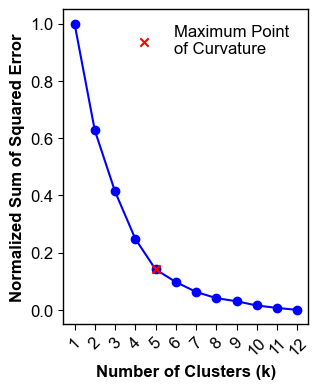

In [22]:
# Create a figure sized so that 70% of the height equals 2.5 inches
fig = plt.figure(figsize=(3.5, 4.5))# 3.5" wide, 3.57" tall
ax = fig.add_axes([0.15, 0.15, 0.7, 0.7])  # 70% of figure area = 2.5" tall

# Plot normalized inertia for scaled data
ax.plot(k_values, inertia_data_scaled, marker='o', linestyle='-', color='blue')

# Optionally plot the unscaled data as well
# ax.plot(k_values, inertia_data, marker='o', linestyle='-', color='green', label='kPCA Transformed Data')

# Labels
ax.set_xlabel('Number of Clusters (k)', fontsize=12, fontname='Arial', fontweight='bold')
ax.set_ylabel('Normalized Sum of Squared Error', fontsize=12, fontname='Arial', fontweight='bold')
ax.set_xticks(np.arange(1, 13, 1))
plt.xticks(np.arange(1, 13, 1), fontsize=12, fontname='Arial', rotation=45)
plt.yticks(fontsize=12, fontname='Arial')
ax.tick_params(axis='x', length=4)

# Frame thickness
for spine in ax.spines.values():
    spine.set_linewidth(1)

# Add the knee point
ax.scatter(kneedle_data_scaled.elbow, kneedle_data_scaled.elbow_y, color='red', marker='x', zorder=4, label='Maximum Point \nof Curvature')

# Add legend and remove the border
legend = ax.legend(prop={'family': 'Arial', 'size': 12})
legend.get_frame().set_linewidth(0)  # Remove the border

# Save and show
plt.savefig(r"Z:\PhD Students\Packard_Sydney\2_Projects and Authored Papers\A_Staphylococcal Dispersed Cells\7_Staph Dispersed Cells Figures\Plots\k-means_scaled_v1.jpeg", dpi=300, bbox_inches="tight")
plt.show()
